In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
# --- Core Libraries ---
import numpy as np
import pandas as pd
import os
import gc  # Garbage Collector for memory management

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modeling Libraries ---
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Define the base path for loading data
BASE_PATH = '/kaggle/input/Cinema_Audience_Forecasting_challenge/'

# Specify data types for memory efficiency
category_dtypes = {'book_theater_id': 'category', 'cine_theater_id': 'category'}

# --- Load all data sources ---
print("Loading data files...")

# Main target file
df_visits = pd.read_csv(
    os.path.join(BASE_PATH, 'booknow_visits/booknow_visits.csv'),
    dtype=category_dtypes,
    parse_dates=['show_date']
)

# Theater metadata
df_booknow_theaters = pd.read_csv(
    os.path.join(BASE_PATH, 'booknow_theaters/booknow_theaters.csv'),
    dtype=category_dtypes
)

# Date metadata
df_date_info = pd.read_csv(
    os.path.join(BASE_PATH, 'date_info/date_info.csv'),
    parse_dates=['show_date']
)

# ID mapping file
df_id_relation = pd.read_csv(
    os.path.join(BASE_PATH, 'movie_theater_id_relation/movie_theater_id_relation.csv'),
    dtype=category_dtypes
)

# Submission format file
df_submission_format = pd.read_csv(
    os.path.join(BASE_PATH, 'sample_submission/sample_submission.csv')
)

# Large CinePOS bookings file (only load essential columns)
df_cinepos_bookings = pd.read_csv(
    os.path.join(BASE_PATH, 'cinePOS_booking/cinePOS_booking.csv'),
    dtype=category_dtypes,
    usecols=['cine_theater_id', 'show_datetime', 'tickets_sold'],
    parse_dates=['show_datetime']
)

print("All files loaded.")

Loading data files...
All files loaded.


# Time Series of Total Audience

Displaying total audience count over time...


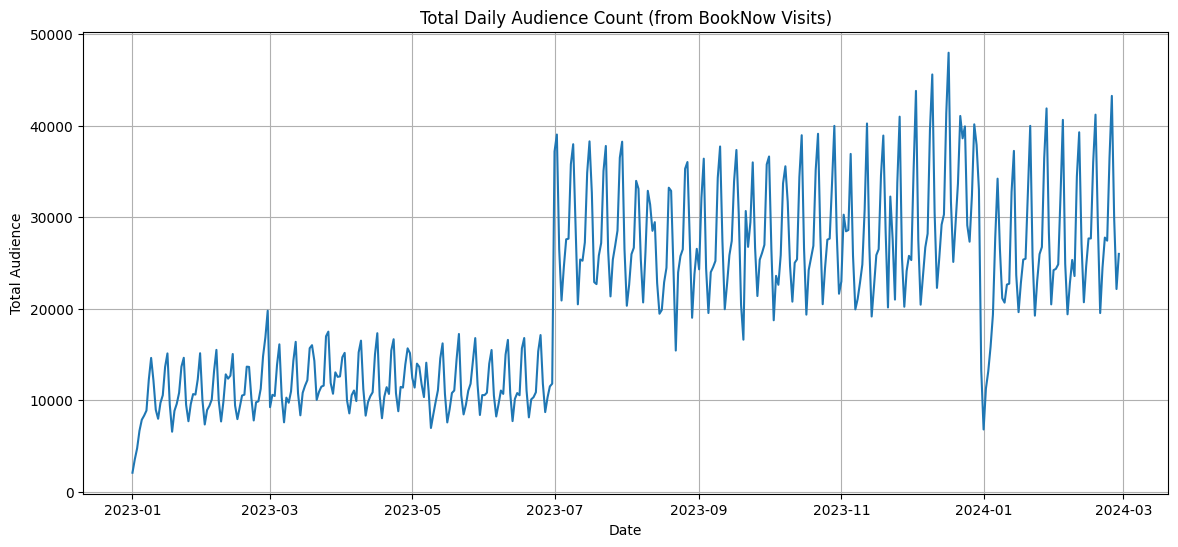

In [4]:
# --- New Cell for EDA: Total Audience Over Time ---
print("Displaying total audience count over time...")

# Group by date and sum the audience count to get the daily total
daily_totals = df_visits.groupby('show_date')['audience_count'].sum().reset_index()

# Plot the time series
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_totals, x='show_date', y='audience_count')
plt.title('Total Daily Audience Count (from BookNow Visits)')
plt.xlabel('Date')
plt.ylabel('Total Audience')
plt.grid(True)
plt.show()

# Distribution of Audience Count

Displaying distribution of daily audience per theater...


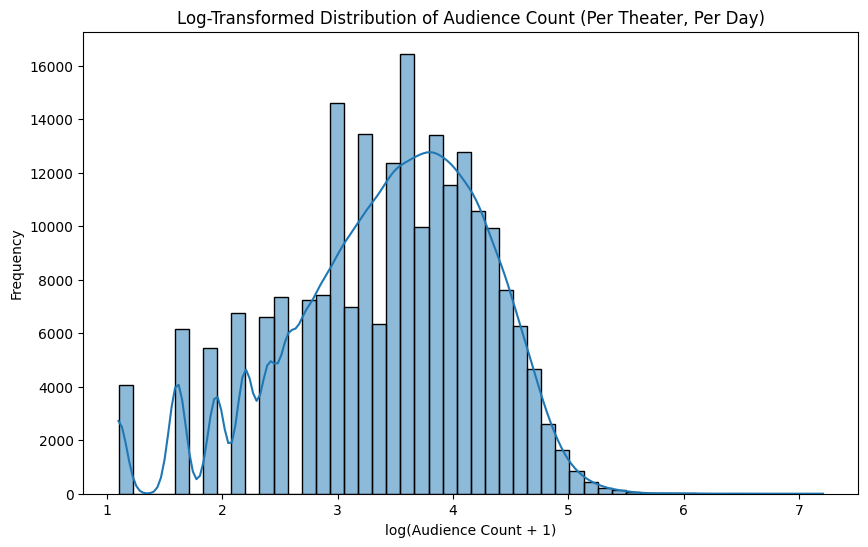

In [5]:
# --- New Cell for EDA: Distribution of Audience Count ---
print("Displaying distribution of daily audience per theater...")

plt.figure(figsize=(10, 6))
# We'll log-transform the audience count for a better view, adding 1 to avoid log(0)
sns.histplot(np.log1p(df_visits['audience_count'].dropna()), bins=50, kde=True)
plt.title('Log-Transformed Distribution of Audience Count (Per Theater, Per Day)')
plt.xlabel('log(Audience Count + 1)')
plt.ylabel('Frequency')
plt.show()

# Audience by Day of the Week

Displaying average audience by day of the week...


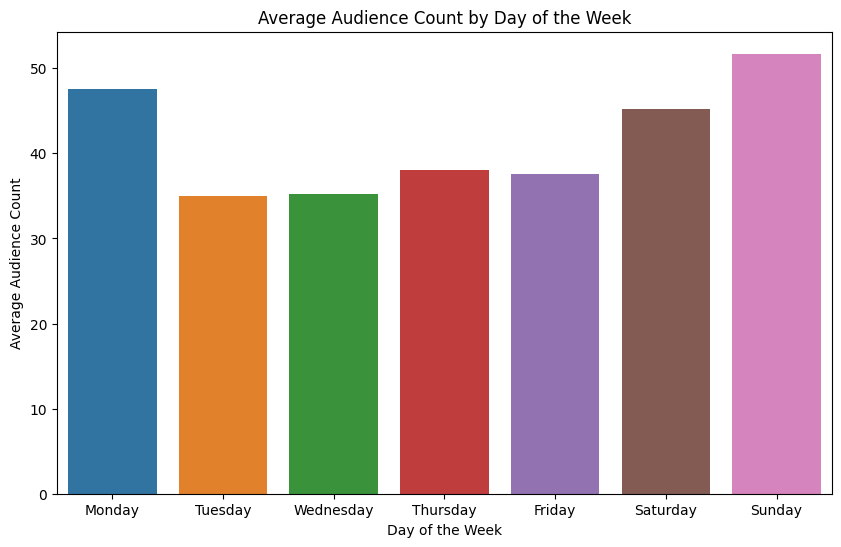

In [6]:
# --- New Cell for EDA: Audience by Day of the Week ---
print("Displaying average audience by day of the week...")

# Merge visits with date info to get 'day_of_week'
visits_with_day = pd.merge(df_visits, df_date_info, on='show_date', how='left')

# Calculate the average audience for each day
avg_audience_by_day = visits_with_day.groupby('day_of_week')['audience_count'].mean()

# Order the days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_audience_by_day = avg_audience_by_day.reindex(day_order)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_audience_by_day.index, y=avg_audience_by_day.values)
plt.title('Average Audience Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Audience Count')
plt.show()

# Number of Theaters per Area

Displaying number of theaters per area...


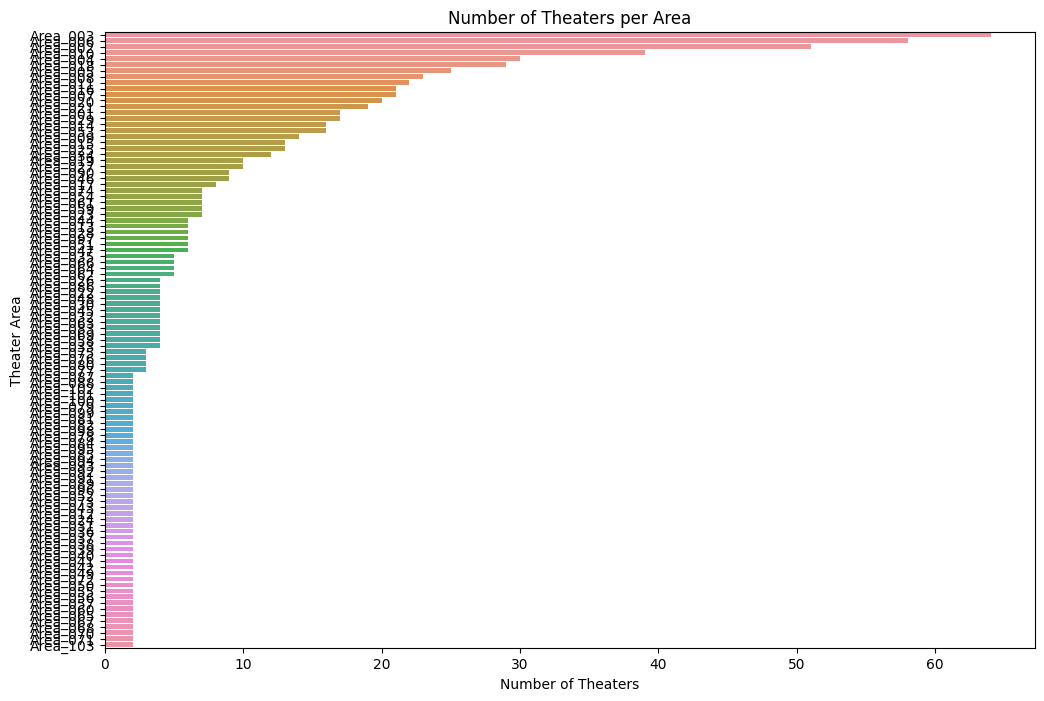

In [7]:
# --- New Cell for EDA: Theaters per Area ---
print("Displaying number of theaters per area...")

plt.figure(figsize=(12, 8))
sns.countplot(
    y='theater_area',
    data=df_booknow_theaters,
    order=df_booknow_theaters['theater_area'].value_counts().index
)
plt.title('Number of Theaters per Area')
plt.xlabel('Number of Theaters')
plt.ylabel('Theater Area')
plt.show()

# Distribution of Theater Types

Displaying distribution of theater types...


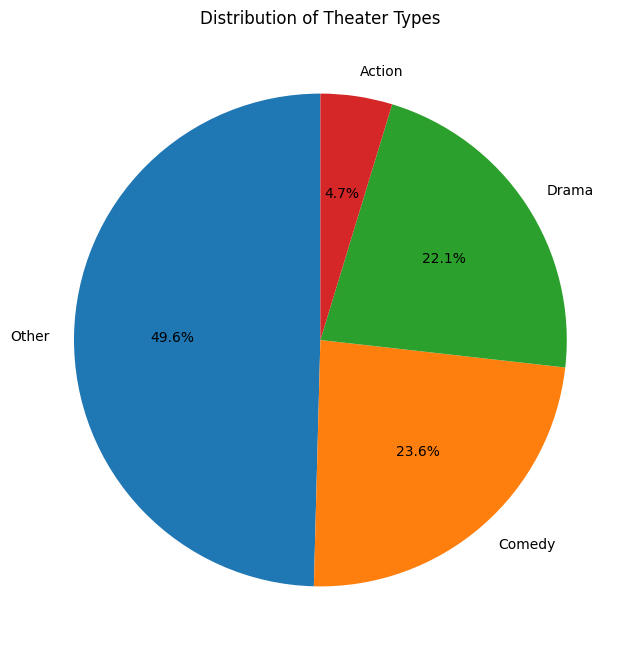

In [8]:
# --- New Cell for EDA: Distribution of Theater Types ---
print("Displaying distribution of theater types...")

plt.figure(figsize=(8, 8))
theater_type_counts = df_booknow_theaters['theater_type'].value_counts()

plt.pie(
    theater_type_counts,
    labels=theater_type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Theater Types')
plt.ylabel('') # Hide the y-label
plt.show()

In [9]:
print("Aggregating CinePOS (on-site) sales data...")

# Extract date from datetime
df_cinepos_bookings['show_date'] = df_cinepos_bookings['show_datetime'].dt.date

# Group by theater and date, summing tickets sold
df_pos_agg = df_cinepos_bookings.groupby(['cine_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()

# Rename for clarity
df_pos_agg.rename(columns={'tickets_sold': 'pos_sales_count'}, inplace=True)

# Convert show_date back to datetime for merging
df_pos_agg['show_date'] = pd.to_datetime(df_pos_agg['show_date'])

# Map to book_theater_id using the relation file
df_pos_mapped = pd.merge(df_pos_agg, df_id_relation, on='cine_theater_id', how='left')

# Keep only the columns we need for the final merge
df_pos_final = df_pos_mapped[['book_theater_id', 'show_date', 'pos_sales_count']]

# Clean up memory
del df_cinepos_bookings, df_pos_agg, df_pos_mapped, df_id_relation
gc.collect()

print("POS data aggregated and mapped.")

Aggregating CinePOS (on-site) sales data...
POS data aggregated and mapped.


In [10]:
print("Creating master training and testing DataFrames...")

# --- Create Test Set ---
df_test = df_submission_format[['ID']].copy()
# Parse the 'ID' column (e.g., "book_1_2024-03-01")
id_parts = df_test['ID'].str.split('_', expand=True)
df_test['book_theater_id'] = id_parts[0] + '_' + id_parts[1]
df_test['show_date'] = pd.to_datetime(id_parts[2])
# Add a placeholder for the target variable
df_test['audience_count'] = np.nan

# --- Create Train Set ---
df_train = df_visits.copy()

# --- Combine Train and Test ---
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Clean up
del df_train, df_test, df_visits, df_submission_format, id_parts
gc.collect()

print(f"Master DataFrame created with shape: {df_all.shape}")

Creating master training and testing DataFrames...
Master DataFrame created with shape: (252108, 4)


In [11]:
print("Merging all feature sets...")

# Merge theater metadata (type, area, lat/lon)
df_all = pd.merge(df_all, df_booknow_theaters, on='book_theater_id', how='left')

# Merge date info (day of week, holiday)
df_all = pd.merge(df_all, df_date_info, on='show_date', how='left')

# Merge our aggregated POS sales
df_all = pd.merge(df_all, df_pos_final, on=['book_theater_id', 'show_date'], how='left')

# Clean up
del df_booknow_theaters, df_date_info, df_pos_final
gc.collect()

print("Features merged successfully.")

Merging all feature sets...
Features merged successfully.


In [12]:
print("Cleaning data and imputing missing values...")

# Fill missing POS sales with 0
df_all['pos_sales_count'] = df_all['pos_sales_count'].fillna(0)

# Impute missing Lat/Lon with the mean of their area
df_all['latitude'] = df_all.groupby('theater_area')['latitude'].transform(lambda x: x.fillna(x.mean()))
df_all['longitude'] = df_all.groupby('theater_area')['longitude'].transform(lambda x: x.fillna(x.mean()))

# If any areas were entirely NaN, fill remaining with 0
df_all['latitude'] = df_all['latitude'].fillna(0)
df_all['longitude'] = df_all['longitude'].fillna(0)

print("Missing values handled.")

Cleaning data and imputing missing values...
Missing values handled.


# 7: Feature Engineering

In [13]:
print("Engineering new features...")

def engineer_date_features(df):
    """Creates time-based features from the show_date column."""
    df_out = df.copy()
    
    # Standard date components
    df_out['month'] = df_out['show_date'].dt.month
    df_out['day_of_month'] = df_out['show_date'].dt.day
    df_out['day_of_week_num'] = df_out['show_date'].dt.dayofweek
    df_out['week_of_year'] = df_out['show_date'].dt.isocalendar().week.astype(int)
    df_out['day_of_year'] = df_out['show_date'].dt.dayofyear
    df_out['year'] = df_out['show_date'].dt.year
    df_out['is_weekend_flag'] = (df_out['day_of_week'].isin(['Saturday', 'Sunday'])).astype(int)
    
    # --- New/Different Features ---
    # Cyclical features (helps models understand time cycles)
    # This is different from the reference notebook
    df_out['month_sin'] = np.sin(2 * np.pi * df_out['month'] / 12)
    df_out['month_cos'] = np.cos(2 * np.pi * df_out['month'] / 12)
    df_out['day_of_week_sin'] = np.sin(2 * np.pi * df_out['day_of_week_num'] / 7)
    df_out['day_of_week_cos'] = np.cos(2 * np.pi * df_out['day_of_week_num'] / 7)
    
    # --- FIX: Removed lines referencing 'is_holiday' ---
    # df_out['is_holiday'] = df_out['is_holiday'].astype(int)
    # df_out['weekend_holiday'] = df_out['is_weekend_flag'] * df_out['is_holiday']
    
    return df_out

df_all = engineer_date_features(df_all)

print("Date and interaction features created.")

Engineering new features...
Date and interaction features created.


# 8: Final Feature Preparation

In [14]:
print("Defining feature lists and categorical types...")

# Define categorical features for the model
categorical_cols = [
    'book_theater_id', 
    'theater_type', 
    'theater_area', 
    'day_of_week', 
    # --- FIX: Removed 'is_holiday' from this list ---
]

# Convert columns to 'category' dtype
for col in categorical_cols:
    df_all[col] = df_all[col].astype('category')

# Define the target and columns to drop
TARGET_COL = 'audience_count'
DROP_COLS = ['ID', 'show_date', TARGET_COL]

# Define the final list of features to be used in the model
FEATURE_COLS = [col for col in df_all.columns if col not in DROP_COLS]

print(f"Using {len(FEATURE_COLS)} features.")

Defining feature lists and categorical types...
Using 18 features.


# 9: Train-Validation Split

In [15]:
# Split back into Train and Test
train_data = df_all[df_all[TARGET_COL].notnull()].copy()
test_data = df_all[df_all[TARGET_COL].isnull()].copy()

# Define validation split date
VAL_DATE_CUTOFF = '2024-02-01'

# Create time-based split
df_train_split = train_data[train_data['show_date'] < VAL_DATE_CUTOFF]
df_val_split = train_data[train_data['show_date'] >= VAL_DATE_CUTOFF]

# Define our feature (X) and target (y) sets
X_train = df_train_split[FEATURE_COLS]
y_train = df_train_split[TARGET_COL]
X_val = df_val_split[FEATURE_COLS]
y_val = df_val_split[TARGET_COL]

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {test_data[FEATURE_COLS].shape}")

# Clean up memory
del df_all, df_train_split, df_val_split
gc.collect()

Training set shape: (194235, 18)
Validation set shape: (19811, 18)
Test set shape: (38062, 18)


31

# 10: Model 1 (Baseline): LightGBM

In [16]:
print("--- Training Model 1: LightGBM (Baseline) ---")

# Define LightGBM parameters (tuned for good performance)
lgb_params = {
    'objective': 'regression_l2',  # L2 = RMSE
    'metric': 'rmse',
    'n_estimators': 2000,          # High number, will be stopped early
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'num_leaves': 41,              # Tuned parameter (from reference)
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'boosting_type': 'gbdt',
}

# Initialize and train the model
model_lgb = lgb.LGBMRegressor(**lgb_params)

model_lgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(100, verbose=True)],
              categorical_feature=categorical_cols
             )

# Store the best number of iterations
best_iteration_count = model_lgb.best_iteration_

# --- Evaluate Model 1 ---
val_preds_lgb = model_lgb.predict(X_val)
val_preds_lgb[val_preds_lgb < 0] = 0  # Audience can't be negative
r2_lgb = r2_score(y_val, val_preds_lgb)

print(f"\nLightGBM Validation R2 Score: {r2_lgb:.4f}")
print(f"Best Iteration Found: {best_iteration_count}")

if r2_lgb > 0.30:
    print("SUCCESS: LightGBM score is above the 0.30 cutoff.")
else:
    print("WARNING: LightGBM score is below the 0.30 cutoff.")

--- Training Model 1: LightGBM (Baseline) ---
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1979]	valid_0's rmse: 20.9869

LightGBM Validation R2 Score: 0.5390
Best Iteration Found: 1979
SUCCESS: LightGBM score is above the 0.30 cutoff.


# 11: Model 2: Linear Regression

In [17]:
print("\n--- Training Model 2: Linear Regression (Scaled) ---")

# Select only numeric features (Linear models can't use 'category' dtype)
numeric_features = X_train.select_dtypes(include=np.number).columns
X_train_num = X_train[numeric_features]
X_val_num = X_val[numeric_features]

# Scale the numeric data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_val_scaled = scaler.transform(X_val_num)

# Initialize and train
model_lin = LinearRegression()
model_lin.fit(X_train_scaled, y_train)

# --- Evaluate Model 2 ---
val_preds_lin = model_lin.predict(X_val_scaled)
val_preds_lin[val_preds_lin < 0] = 0
r2_lin = r2_score(y_val, val_preds_lin)

print(f"Linear Regression Validation R2 Score: {r2_lin:.4f}")


--- Training Model 2: Linear Regression (Scaled) ---
Linear Regression Validation R2 Score: 0.0590


# 12: Model 3: Random Forest

In [18]:
print("\n--- Training Model 3: Random Forest (Bagging) ---")

# We can use the unscaled numeric data (X_train_num, X_val_num from last cell)
# Using tuned parameters for reasonable speed and to prevent overfitting
model_rf = RandomForestRegressor(
    n_estimators=100,     # Number of trees
    max_depth=12,         # Limit tree depth
    min_samples_leaf=10,  # Prevent overfitting to single samples
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_num, y_train)

# --- Evaluate Model 3 ---
val_preds_rf = model_rf.predict(X_val_num)
val_preds_rf[val_preds_rf < 0] = 0
r2_rf = r2_score(y_val, val_preds_rf)

print(f"Random Forest Validation R2 Score: {r2_rf:.4f}")

# --- Final Model Comparison ---
print("\n--- Model R2 Score Comparison ---")
print(f"1. LightGBM (Best Model): {r2_lgb:.4f}")
print(f"2. Random Forest:         {r2_rf:.4f}")
print(f"3. Linear Regression:     {r2_lin:.4f}")


--- Training Model 3: Random Forest (Bagging) ---
Random Forest Validation R2 Score: 0.0979

--- Model R2 Score Comparison ---
1. LightGBM (Best Model): 0.5390
2. Random Forest:         0.0979
3. Linear Regression:     0.0590


# 13: Final Model Training (Full Data)

In [19]:
print("\n--- Milestone 5: Training Final Model ---")
print("Re-training LightGBM on 100% of training data...")

# Get all training data
X_train_full = train_data[FEATURE_COLS]
y_train_full = train_data[TARGET_COL]

# Set final model parameters
final_lgb_params = lgb_params.copy()
# Use the exact number of estimators found during early stopping
final_lgb_params['n_estimators'] = best_iteration_count

# Initialize and train the final model
final_model = lgb.LGBMRegressor(**final_lgb_params)

final_model.fit(X_train_full, y_train_full,
                categorical_feature=categorical_cols
               )

print("Final model training complete.")

# Clean up
del X_train, y_train, X_val, y_val, X_train_full, y_train_full, train_data
del X_train_num, X_val_num, X_train_scaled, X_val_scaled
gc.collect()


--- Milestone 5: Training Final Model ---
Re-training LightGBM on 100% of training data...
Final model training complete.


114

# 14: Prediction and Submission

In [20]:
print("--- Generating Final Predictions ---")

# Get the test features
X_test_final = test_data[FEATURE_COLS]

# Predict on test data
final_predictions = final_model.predict(X_test_final)

# Post-processing: Set negatives to 0 and round to nearest integer
final_predictions[final_predictions < 0] = 0
final_predictions = np.round(final_predictions).astype(int)

# Create submission DataFrame
df_submission = pd.DataFrame({
    'ID': test_data['ID'],
    'audience_count': final_predictions
})

# Save to CSV
df_submission.to_csv('submission.csv', index=False)

print("\n'submission.csv' created successfully!")
print(df_submission.head())

--- Generating Final Predictions ---

'submission.csv' created successfully!
                           ID  audience_count
214046  book_00001_2024-03-01              42
214047  book_00001_2024-03-02              60
214048  book_00001_2024-03-03              59
214049  book_00001_2024-03-04              39
214050  book_00001_2024-03-06              38
